# ADMM Residuals Plotting

This notebook plots primal and dual residuals from ADMM iteration output files.

In [52]:
import numpy as np
import matplotlib.pyplot as plt

In [53]:
def parse_padmm_file(filename):
    """
    Parse PADMM output file and extract iteration data.
    
    PADMM files have a format where multiple iterations can appear on a single line.
    Each iteration has 7 columns: Iter, Time, Objective, Prml Rsdl, Dual Rsdl, SNR, distance
    
    Returns:
        iterations: array of iteration numbers
        objectives: array of objective values
        primal_residuals: array of primal residuals
        dual_residuals: array of dual residuals
        snr: array of SNR values
        distance: array of distance values
    """
    iterations = []
    objectives = []
    primal_residuals = []
    dual_residuals = []
    snr = []
    distance = []
    
    with open(filename, 'r') as f:
        lines = f.readlines()
    
    # Find the header line
    header_found = False
    for i, line in enumerate(lines):
        if 'Iter' in line and 'Prml Rsdl' in line and 'Dual Rsdl' in line:
            header_found = True
            # Skip the separator line
            start_idx = i + 2
            break
    
    if not header_found:
        raise ValueError("Could not find header line in file")
    
    # Parse data lines
    for line in lines[start_idx:]:
        line = line.strip()
        
        # Skip empty lines
        if not line:
            continue
        
        # Skip lines that look like summary/end messages (e.g., "TV Restruction", "SNR:")
        if line.startswith('TV') or line.startswith('SNR:') or 'Restruction' in line:
            continue
        
        # Split the line into parts
        parts = line.split()
        
        # Each iteration has 7 columns: Iter, Time, Objective, Prml Rsdl, Dual Rsdl, SNR, distance
        # Process all iterations on this line (multiple iterations can be on one line)
        num_iterations = len(parts) // 7
        
        # Process each complete iteration (7 columns each)
        for i in range(num_iterations):
            start_col = i * 7
            end_col = start_col + 7
            
            if end_col > len(parts):
                break
            
            try:
                iter_parts = parts[start_col:end_col]
                
                # Column 0: iteration number
                iter_num = int(iter_parts[0])
                
                # Column 2: objective
                obj_str = iter_parts[2]
                if obj_str.lower() == 'inf':
                    obj = np.inf
                else:
                    obj = float(obj_str)
                
                # Column 3: primal residual
                primal = float(iter_parts[3])
                
                # Column 4: dual residual
                dual = float(iter_parts[4])
                
                # Column 5: SNR
                snr_val = float(iter_parts[5])
                
                # Column 6: distance
                dist_val = float(iter_parts[6])
                
                iterations.append(iter_num)
                objectives.append(obj)
                primal_residuals.append(primal)
                dual_residuals.append(dual)
                snr.append(snr_val)
                distance.append(dist_val)
                
            except (ValueError, IndexError) as e:
                # Skip this iteration if parsing fails
                continue
    
    return (np.array(iterations), np.array(objectives), np.array(primal_residuals), 
            np.array(dual_residuals), np.array(snr), np.array(distance))

In [54]:
def parse_admm_file(filename):
    """
    Parse ADMM output file and extract iteration data.
    
    Returns:
        iterations: array of iteration numbers
        objectives: array of objective values
        primal_residuals: array of primal residuals
        dual_residuals: array of dual residuals
        regularization: array of regularization term values
        constraint: array of constraint term values
    """
    iterations = []
    objectives = []
    primal_residuals = []
    dual_residuals = []
    regularization = []
    constraint = []
    
    with open(filename, 'r') as f:
        lines = f.readlines()
    
    # Find the header line
    header_found = False
    for i, line in enumerate(lines):
        if 'Iter' in line and 'Prml Rsdl' in line and 'Dual Rsdl' in line:
            header_found = True
            # Skip the separator line
            start_idx = i + 2
            break
    
    if not header_found:
        raise ValueError("Could not find header line in file")
    
    # Parse data lines
    for line in lines[start_idx:]:
        line = line.strip()
        
        # Skip empty lines and "τ is doubled" messages
        if not line or 'τ is doubled' in line:
            continue
        
        # Try to parse the line as a data row
        # Format: "  73  8.91e+01  4.755e+05  7.899e+03  3.760e+02  7.878e+03  1.220e+03"
        # Column order: Iter, Time, Objective, Prml Rsdl, Dual Rsdl, Regularization, Constraint
        parts = line.split()
        
        if len(parts) >= 5:
            try:
                # Column 0: iteration, Column 2: objective, Column 3: primal residual, Column 4: dual residual
                iter_num = int(parts[0])
                # Handle 'inf' for objective
                obj_str = parts[2]
                if obj_str.lower() == 'inf':
                    obj = np.inf
                else:
                    obj = float(obj_str)
                primal = float(parts[3])
                dual = float(parts[4])
                
                iterations.append(iter_num)
                objectives.append(obj)
                primal_residuals.append(primal)
                dual_residuals.append(dual)
                
                # Extract regularization and constraint if available (columns 5 and 6)
                if len(parts) >= 7:
                    regularization.append(float(parts[5]))
                    constraint.append(float(parts[6]))
                else:
                    regularization.append(np.nan)
                    constraint.append(np.nan)
            except (ValueError, IndexError):
                # Skip lines that don't match the expected format
                continue
    
    return np.array(iterations), np.array(objectives), np.array(primal_residuals), np.array(dual_residuals), np.array(regularization), np.array(constraint)

## Configuration

Specify the path to your ADMM output file:

In [55]:
# Update this path to point to your ADMM output file
SNR = "50"
num_views = "100"
rho = "5e1"
regularization_coeff = "2e0"
maxiter = "2000"
regularization_type = "tv"
Nx = 512
Nz = 512
Ny = 512
N_sphere = 100
save = False

# input_file = f"results/semi_pjadmm_parallel_{regularization_type}_fbp_noisy_sinogram_snr{SNR}_2_2_N_sphere{N_sphere}_l2_plus_reg/ct_mbirjax_3d_{regularization_type}_semi_pjadmm_l2_plus_reg_sinogram_snr{SNR}_ρ{rho}_regularization{regularization_coeff}_n_projection{num_views}_maxiter{maxiter}.txt"
# input_file_no_tau_decrease = f"results/semi_pjadmm_parallel_{regularization_type}_fbp_noisy_sinogram_snr{SNR}_2_2_N_sphere100_l2_plus_reg_no_tau_decrease/ct_mbirjax_3d_{regularization_type}_semi_pjadmm_l2_plus_reg_sinogram_snr{SNR}_ρ{rho}_regularization{regularization_coeff}_n_projection{num_views}_maxiter{maxiter}_no_tau_decrease.txt"
# input_file = f"results/semi_pjadmm_parallel_{regularization_type}_fbp_noisy_sinogram_snr{SNR}_2_2_N_sphere{N_sphere}_l2_plus_reg_parameter_tuning/ct_mbirjax_3d_{regularization_type}_semi_pjadmm_l2_plus_reg_sinogram_snr{SNR}_ρ{rho}_regularization{regularization_coeff}_n_projection{num_views}_maxiter{maxiter}.txt"
# input_file = f"results/semi_pjadmm_parallel_{regularization_type}_fbp_noisy_sinogram_snr{SNR}_2_2_N_sphere{N_sphere}_l2_plus_reg/ct_mbirjax_3d_{regularization_type}_semi_pjadmm_l2_plus_reg_Nx{Nx}_Ny{Ny}_Nz{Nz}_sinogram_snr{SNR}_ρ{rho}_regularization{regularization_coeff}_n_projection{num_views}_maxiter{maxiter}.txt"
# input_file = f"results/semi_pjadmm_parallel_{regularization_type}_fbp_noisy_sinogram_snr{SNR}_2_2_N_sphere{N_sphere}_l2_plus_reg_parameter_tuning/ct_mbirjax_3d_{regularization_type}_semi_pjadmm_l2_plus_reg_Nx{Nx}_Ny{Ny}_Nz{Nz}_sinogram_snr{SNR}_ρ{rho}_regularization{regularization_coeff}_n_projection{num_views}_maxiter{maxiter}.txt"
input_file = f"results/semi_pjadmm_parallel_{regularization_type}_fbp_noisy_sinogram_snr{SNR}_2_2_N_sphere{N_sphere}_l2_plus_reg_corrected_residuals/ct_mbirjax_3d_{regularization_type}_semi_pjadmm_l2_plus_reg_Nx{Nx}_Ny{Ny}_Nz{Nz}_sinogram_snr{SNR}_ρ{rho}_regularization{regularization_coeff}_n_projection{num_views}_maxiter{maxiter}.txt"

# input_file_comparison = f"results/semi_pjadmm_parallel_{regularization_type}_fbp_noisy_sinogram_snr{SNR}_2_2_N_sphere{N_sphere}_l2_plus_reg_corrected_residuals/ct_mbirjax_3d_{regularization_type}_semi_pjadmm_l2_plus_reg_Nx{Nx}_Ny{Ny}_Nz{Nz}_sinogram_snr{SNR}_ρ5e1_regularization{regularization_coeff}_n_projection{num_views}_maxiter{maxiter}.txt"

In [56]:
rho_padmm = "5e-2"

# input_file_padmm = f'results/ct_astra_3d_{regularization_type}_padmm_fbp_initial_l2_plus_reg/{num_views}views_512x512x512_snr{SNR}_rho5e-1_regularization2_maxiter{1000}.txt'
# input_file_padmm = f'results/ct_astra_3d_{regularization_type}_padmm_fbp_initial_l2_plus_reg/{num_views}views_512x512x512_snr{SNR}_rho5e-3_regularization2_maxiter{1000}.txt'
# input_file_padmm = f'results/ct_astra_3d_padmm_l2_plus_reg_parameter_tuning/ct_mbirjax_3d_{regularization_type}_padmm_l2_plus_reg_Nx512_Ny512_Nz512_sinogram_snr{SNR}_ρ{rho_padmm}_regularization2e0_n_projection{num_views}_maxiter1000.txt'
input_file_padmm = f'results/ct_astra_3d_tv_padmm_fbp_initial_l2_plus_reg/ct_astra_3d_tv_padmm_l2_plus_reg_Nx512_Ny512_Nz512_sinogram_snr{SNR}_ρ5e-2_regularization2e0_n_projection100_maxiter5000.txt'

## Parse Data

In [57]:
print(f"Parsing file: {input_file}")
iterations, objectives, primal_residuals, dual_residuals, regularization, constraint = parse_admm_file(input_file)
# iterations_comparison, objectives_comparison, primal_residuals_comparison, dual_residuals_comparison, regularization_comparison, constraint_comparison = parse_admm_file(input_file_comparison)
iterations_padmm, objectives_padmm, primal_residuals_padmm, dual_residuals_padmm, regularization_padmm, constraint_padmm = parse_padmm_file(input_file_padmm)
# iterations_no_tau_decrease, objectives_no_tau_decrease, primal_residuals_no_tau_decrease, dual_residuals_no_tau_decrease, regularization_no_tau_decrease, constraint_no_tau_decrease = parse_admm_file(input_file_no_tau_decrease)

# Moving average for smoother residual plots (adjust window to taste)
def moving_average(x, window):
    """Uniform moving average; same length as x (boundary uses partial window)."""
    return np.convolve(x, np.ones(window) / window, mode="same")

smooth_window = 100
primal_residuals_smooth = moving_average(primal_residuals, smooth_window)
# primal_residuals_smooth_comparison = moving_average(primal_residuals_comparison, smooth_window)
primal_residuals_smooth_padmm = moving_average(primal_residuals_padmm, smooth_window)

dual_residuals_smooth = moving_average(dual_residuals, smooth_window)

Parsing file: results/semi_pjadmm_parallel_tv_fbp_noisy_sinogram_snr50_2_2_N_sphere100_l2_plus_reg_corrected_residuals/ct_mbirjax_3d_tv_semi_pjadmm_l2_plus_reg_Nx512_Ny512_Nz512_sinogram_snr50_ρ5e1_regularization2e0_n_projection100_maxiter2000.txt


In [58]:
def analyze_convergence(values, name="values"):
    """
    Analyze whether a sequence is decreasing and report statistics.
    """
    values = np.array(values)
    n = len(values)
    if n < 2:
        print(f"{name}: Not enough data points")
        return
    
    # Overall trend: compare first and last values
    start_val = values[0]
    end_val = values[-1]
    overall_decrease = (end_val < start_val)
    ratio = end_val / start_val if start_val != 0 else float('inf')
    
    # Count decreasing steps
    diffs = np.diff(values)
    decreasing_steps = np.sum(diffs < 0)
    pct_decreasing = 100 * decreasing_steps / (n - 1)
    
    # Fit linear regression to log values (for exponential decay check)
    log_values = np.log(values[values > 0])
    if len(log_values) > 1:
        x = np.arange(len(log_values))
        slope, intercept = np.polyfit(x, log_values, 1)
        decay_rate = -slope  # positive = decreasing
    else:
        decay_rate = None
    
    print(f"\n{name}:")
    print(f"  Start: {start_val:.6e}, End: {end_val:.6e}")
    print(f"  Overall decreasing: {overall_decrease} (ratio end/start = {ratio:.4f})")
    print(f"  Decreasing steps: {decreasing_steps}/{n-1} ({pct_decreasing:.1f}%)")
    if decay_rate is not None:
        print(f"  Log-linear slope: {-decay_rate:.6f} ({'decreasing' if decay_rate > 0 else 'increasing'})")
    
    return overall_decrease, pct_decreasing, decay_rate

In [59]:
starting_index_decreament_test = 1000
analyze_convergence(primal_residuals_smooth[starting_index_decreament_test:], "Primal Residuals (smoothed)")
analyze_convergence(dual_residuals_smooth[starting_index_decreament_test:], "Dual Residuals (smoothed)")


Primal Residuals (smoothed):
  Start: 3.062207e-01, End: 1.142356e-01
  Overall decreasing: True (ratio end/start = 0.3730)
  Decreasing steps: 588/999 (58.9%)
  Log-linear slope: -0.000404 (decreasing)

Dual Residuals (smoothed):
  Start: 6.399178e+03, End: 2.385610e+03
  Overall decreasing: True (ratio end/start = 0.3728)
  Decreasing steps: 585/999 (58.6%)
  Log-linear slope: -0.000411 (decreasing)


(np.True_, np.float64(58.55855855855856), np.float64(0.00041076198101075906))

## Calculate Exact Objective Value

In [60]:
# def noisy_sinogram(sinogram, snr_db=30, use_variance=True, save_path=None):
#     """Add Poisson noise to the sinogram, so that SNR is around snr_db dB."""
#     # Set the seed for reproducibility.
#     seed = 42
#     np.random.seed(seed)

#     if use_variance:
#         P_signal = np.mean((sinogram - sinogram.mean())**2)
#     else:
#         P_signal = np.mean(sinogram**2)

#     sigma_n = np.sqrt(P_signal / (10**(snr_db/10.0)))
#     noise = np.random.normal(0.0, sigma_n, size=sinogram.shape).astype(np.float32)
#     sinogram_noisy = sinogram + noise
#     if save_path is not None:
#         save_recon_comparision(sinogram, sinogram_noisy, save_path)
#     return sinogram_noisy, noise

In [61]:
# from scico.examples import create_tangle_phantom, create_3d_foam_phantom
# from scico.functional import IsotropicTVNorm, L1Norm
# from scico import functional, linop, loss, metric, plot
# from scico.linop.xray.astra import XRayTransform3D, angle_to_vector

# x_gt = create_3d_foam_phantom(im_shape=(Nz, Ny, Nx), N_sphere=N_sphere)
# if regularization_type == "tv":
#     true_regularization = IsotropicTVNorm(input_shape=(Nz, Ny, Nx))
# elif regularization_type == "l1":
#     true_regularization = L1Norm()

# angles = np.linspace(0, np.pi, int(num_views), endpoint=False)  # evenly spaced projection angles
# det_spacing = [1.0, 1.0]
# det_count = [Nz, max(Nx, Ny)]
# vectors = angle_to_vector(det_spacing, angles)
# C = XRayTransform3D(x_gt.shape, det_count=det_count, vectors=vectors)  # CT projection operator
# y = C @ x_gt  # sinogram
# # print(f"SNR of sinogram: {snr_db} dB")
# if SNR != "inf":
#     snr_db = int(SNR)
#     y_noisy, noise = noisy_sinogram(y, snr_db=snr_db, use_variance=True, save_path=None)
# else:
#     y_noisy = y

In [62]:
# true_objective = float(regularization_coeff) * true_regularization(x_gt) + 0.5 * np.linalg.norm(y_noisy - y)**2
# print(f"True objective: {true_objective}")
# print(f"True regularization: {float(regularization_coeff) * true_regularization(x_gt)}")
# print(f"True constraint: {0.5 * np.linalg.norm(y_noisy - y)**2}")

In [63]:
# print("SNR of sinogram is", round(metric.snr(y, y_noisy)))

# Plot

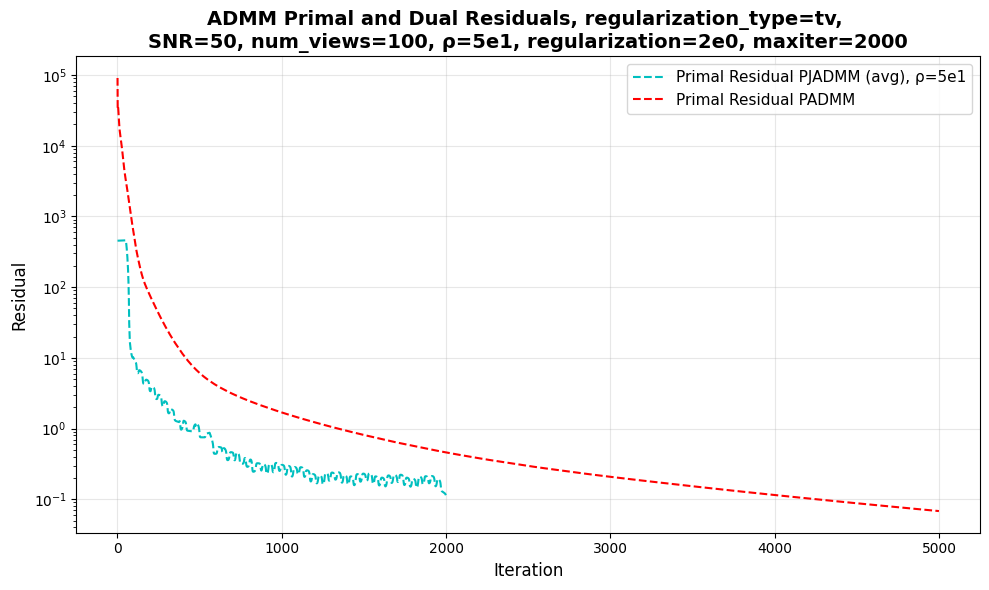

In [64]:
# Plot Residuals (smoothed with moving average to reduce oscillation)
plt.figure(figsize=(10, 6))

'''
PJADMM Part
'''
# plt.semilogy(iterations[1:2000], primal_residuals[1:2000], 'c-', label='Primal Residual PJADMM', alpha=0.3, linewidth=1.5)
plt.semilogy(iterations[1:], primal_residuals_smooth[1:], 'c--', label=f'Primal Residual PJADMM (avg), ρ={rho}', linewidth=1.5)
# plt.semilogy(iterations[1:], dual_residuals[1:], 'r-', label='Dual Residual', linewidth=1.5)
# plt.semilogy(iterations[1:], dual_residuals_smooth[1:], 'b-', label='Dual Residual (avg)', linewidth=1.5)


# plt.semilogy(iterations_comparison[1:2000], primal_residuals_comparison[1:2000], 'g-', label='Primal Residual PJADMM (avg) Comparison', linewidth=1.5)
# plt.semilogy(iterations_comparison[1:], primal_residuals_smooth_comparison[1:], 'g--', label='Primal Residual PJADMM (avg), ρ=5e1', linewidth=1.5)

# plt.semilogy(iterations_no_tau_decrease[1:], primal_residuals_no_tau_decrease[1:], 'b--', label='Primal Residual (no τ decrease)', linewidth=1.5)
# plt.semilogy(iterations_no_tau_decrease[1:], dual_residuals_no_tau_decrease[1:], 'r--', label='Dual Residual (no τ decrease)', linewidth=1.5)

'''
PADMM Part
'''
plt.semilogy(iterations_padmm[1:], primal_residuals_padmm[1:], 'r--', label='Primal Residual PADMM', linewidth=1.5)
# plt.semilogy(iterations_padmm[1:], dual_residuals_padmm[1:], 'g--', label='Dual Residual PADMM', linewidth=1.5)
# plt.semilogy(iterations_padmm[1:], primal_residuals_smooth_padmm[1:], 'b--', label='Primal Residual PADMM (avg)', linewidth=1.5)


'''
Plot Configs
'''
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Residual', fontsize=12)
plt.title(f'ADMM Primal and Dual Residuals, regularization_type={regularization_type}, \nSNR={SNR}, num_views={num_views}, ρ={rho}, regularization={regularization_coeff}, maxiter={maxiter}', fontsize=14, fontweight='bold')

plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Set y-axis ticks to be every 10^n
from matplotlib.ticker import LogLocator
ax = plt.gca()
plt.tight_layout()

if save:
    output_file = f"results/residual_plots/semi_pjadmm_residuals_regularization_type{regularization_type}_Nx{Nx}_Ny{Ny}_Nz{Nz}_snr{SNR}_num_views{num_views}_rho{rho}_regularization{regularization_coeff}_maxiter{maxiter}_l2_plus_reg.png"
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"Plot saved to {output_file}")

plt.show()

In [65]:
# The proximal parameter of the PJADMM is around 4e-4 to 8e-4
# I have no idea why it still does not converge.

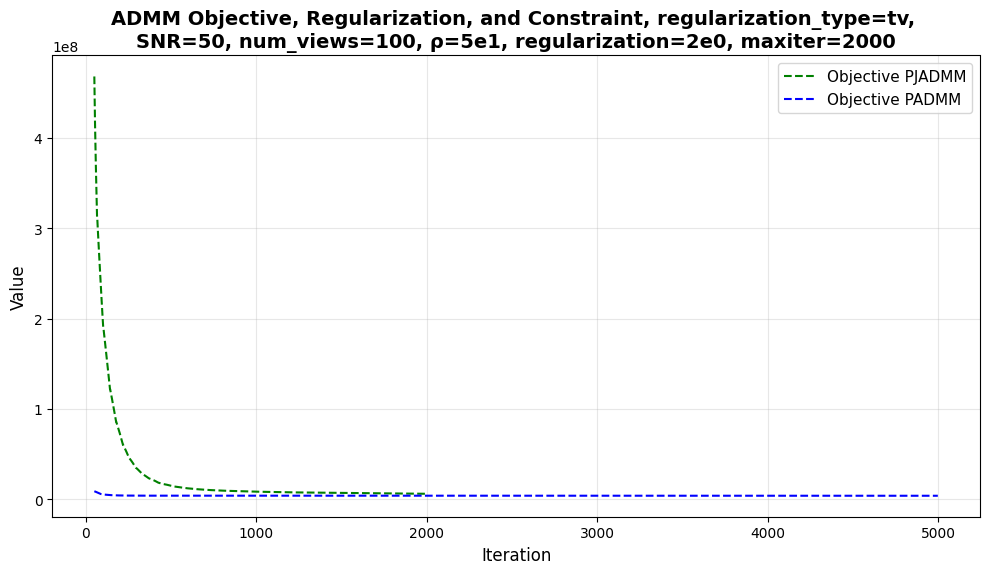

In [66]:
# TODO: Check why the initial objectives are drastically different.
# TODO: Run for more iterations...

# Plot Objectives, Regularization, and Constraint
plt.figure(figsize=(10, 6))
start_index = 50

# Filter out inf values for plotting
valid_mask = (objectives != np.inf) & (objectives > 0)
valid_mask_padmm = (objectives_padmm != np.inf) & (objectives_padmm > 0)

plt.plot(iterations[valid_mask][start_index:], objectives[valid_mask][start_index:], 'g--', label='Objective PJADMM', linewidth=1.5)
plt.plot(iterations_padmm[valid_mask_padmm][start_index:], objectives_padmm[valid_mask_padmm][start_index:], 'b--', label='Objective PADMM', linewidth=1.5)

# plt.axhline(y=true_objective, color='r', linestyle='-', label='True Objective', linewidth=1.5)
# print("True objective:", true_objective)

# # Plot regularization and constraint terms if available
# if not np.all(np.isnan(regularization)):
#     reg_valid_mask = valid_mask & ~np.isnan(regularization) & (regularization > 0)
#     if np.any(reg_valid_mask):
#         plt.plot(iterations[reg_valid_mask][start_index:], regularization[reg_valid_mask][start_index:], 'b-', label='Regularization', linewidth=1.5)

# if not np.all(np.isnan(constraint)):
#     const_valid_mask = valid_mask & ~np.isnan(constraint) & (constraint > 0)
#     if np.any(const_valid_mask):
#         plt.plot(iterations[const_valid_mask][start_index:], constraint[const_valid_mask][start_index:], 'r-', label='Constraint', linewidth=1.5)

plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.title(f'ADMM Objective, Regularization, and Constraint, regularization_type={regularization_type}, \nSNR={SNR}, num_views={num_views}, ρ={rho}, regularization={regularization_coeff}, maxiter={maxiter}', fontsize=14, fontweight='bold')

plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()

if save:
    output_file = f"results/residual_plots/semi_pjadmm_objectives_regularization_type{regularization_type}_Nx{Nx}_Ny{Ny}_Nz{Nz}_snr{SNR}_num_views{num_views}_rho{rho}_regularization{regularization_coeff}_maxiter{maxiter}.png"
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"Plot saved to {output_file}")

plt.show()

Final objective ratio: 1.5380260890967266


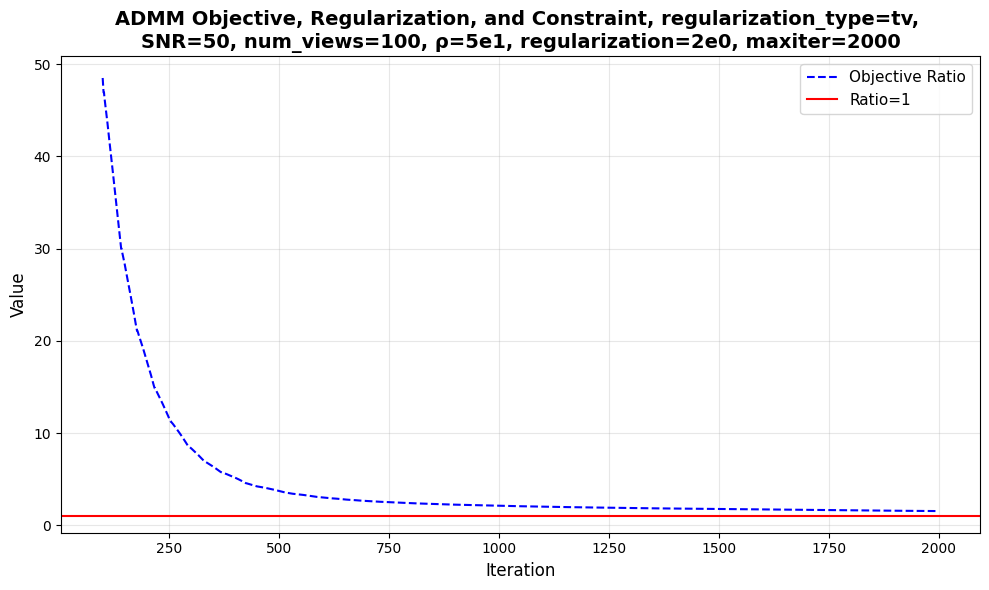

In [67]:
# TODO: Plot a log-Y plot that shows the difference between best PJADMM (eg. 2000 iterations)
# and the PADMM objective. Or maybe quotient?

# Plot Objectives, Regularization, and Constraint
plt.figure(figsize=(10, 6))
start_index = 100

# Filter out inf values for plotting
valid_mask = (objectives != np.inf) & (objectives > 0)

final_padmm_objective = objectives_padmm[-1]
plt.plot(iterations[valid_mask][start_index:], objectives[valid_mask][start_index:] / final_padmm_objective, 'b--', label='Objective Ratio', linewidth=1.5)
print("Final objective ratio:", objectives[valid_mask][-1] / final_padmm_objective)

plt.axhline(y=1, color='r', linestyle='-', label='Ratio=1', linewidth=1.5)

plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.title(f'ADMM Objective, Regularization, and Constraint, regularization_type={regularization_type}, \nSNR={SNR}, num_views={num_views}, ρ={rho}, regularization={regularization_coeff}, maxiter={maxiter}', fontsize=14, fontweight='bold')

plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()

if save:
    output_file = f"results/residual_plots/semi_pjadmm_objectives_regularization_type{regularization_type}_Nx{Nx}_Ny{Ny}_Nz{Nz}_snr{SNR}_num_views{num_views}_rho{rho}_regularization{regularization_coeff}_maxiter{maxiter}.png"
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"Plot saved to {output_file}")

plt.show()